# Linear Regression on Boston Housing Dataset

This data was originally a part of UCI Machine Learning Repository and has been removed now. This data also ships with the scikit-learn library. 
There are 506 samples and 13 feature variables in this data-set. The objective is to predict the value of prices of the house using the given features.

The description of all the features is given below:

  **CRIM**: Per capita crime rate by town

  **ZN**: Proportion of residential land zoned for lots over 25,000 sq. ft

  **INDUS**: Proportion of non-retail business acres per town

  **CHAS**: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)

  **NOX**: Nitric oxide concentration (parts per 10 million)

  **RM**: Average number of rooms per dwelling

  **AGE**: Proportion of owner-occupied units built prior to 1940

  **DIS**: Weighted distances to five Boston employment centers

  **RAD**: Index of accessibility to radial highways

  **TAX**: Full-value property tax rate per $10,000

  **B**: 1000(Bk - 0.63)², where Bk is the proportion of [people of African American descent] by town

  **LSTAT**: Percentage of lower status of the population

  **MEDV**: Median value of owner-occupied homes in $1000s




I**mport the required Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

import pandas as pd  
import seaborn as sns 

%matplotlib inline

**Load the Boston Housing DataSet from scikit-learn**

In [2]:
from sklearn.datasets import load_boston

boston_dataset = load_boston()

# boston_dataset is a dictionary
# let's check what it contains
boston_dataset.keys()

dict_keys(['data', 'target', 'feature_names', 'DESCR', 'filename'])

**Load the data into pandas dataframe**

In [3]:
boston = pd.DataFrame(boston_dataset.data, columns=boston_dataset.feature_names)
boston.head()
# temp = pd.DataFrame(boston_dataset.data, columns=boston_dataset.feature_names)
# print(temp)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


**The target values is missing from the data. Create a new column of target values and add it to dataframe**

In [4]:
boston['MEDV'] = boston_dataset.target

**Data preprocessing**

In [5]:
# check for missing values in all the columns
boston.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

**Data Visualization**

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


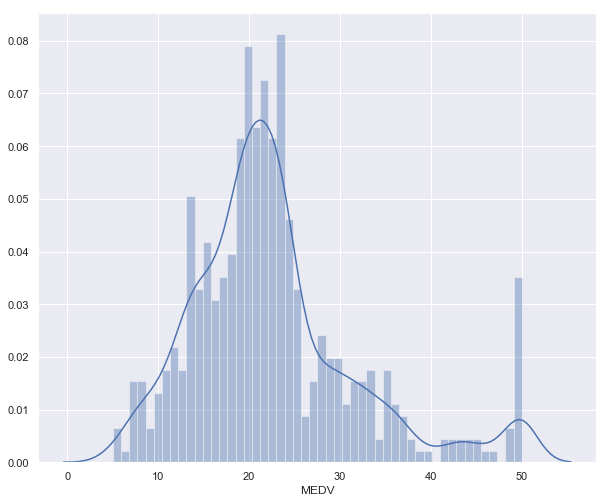

In [6]:
# set the size of the figure
sns.set(rc={'figure.figsize':(10,8.27)})

# plot a histogram showing the distribution of the target values
sns.distplot(boston['MEDV'], bins=50)
plt.show()

**Correlation matrix**

In [7]:
# compute the pair wise correlation for all columns  
correlation_matrix = boston.corr().round(2)

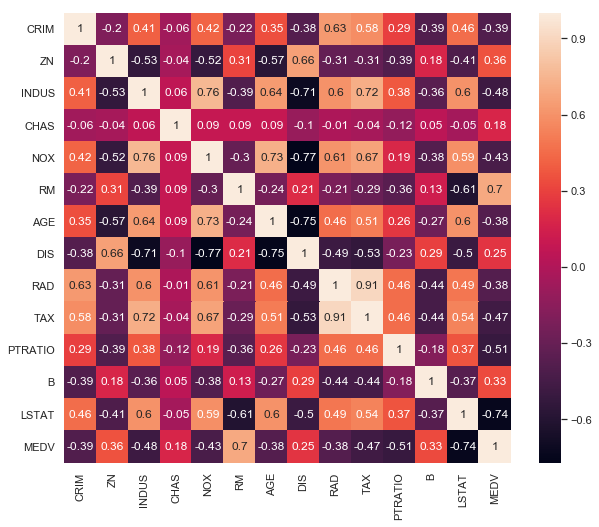

In [8]:
# use the heatmap function from seaborn to plot the correlation matrix
# annot = True to print the values inside the square
sns.heatmap(data=correlation_matrix, annot=True)

**Observations**




*   From the above coorelation plot we can see that **MEDV** is strongly correlated to **LSTAT**, **RM**




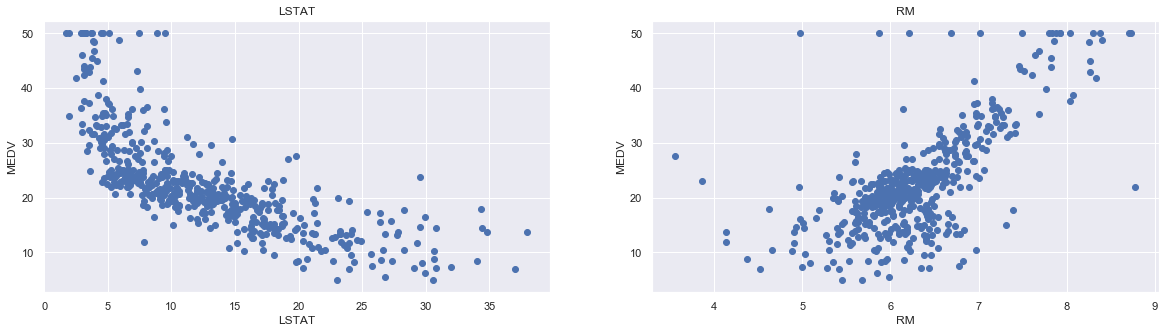

In [9]:
plt.figure(figsize=(20, 5))

features = ['LSTAT', 'RM']
target = boston['MEDV']

for i, col in enumerate(features):
    plt.subplot(1, len(features) , i+1)
    x = boston[col]
    y = target
    plt.scatter(x, y, marker='o')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('MEDV')

**Prepare the data for training**

In [10]:
X = pd.DataFrame(np.c_[boston['LSTAT'], boston['RM']], columns = ['LSTAT','RM'])
# X = boston.loc[:, boston.columns != 'MEDV']
Y = boston['MEDV']
print("X",X)

X      LSTAT     RM
0     4.98  6.575
1     9.14  6.421
2     4.03  7.185
3     2.94  6.998
4     5.33  7.147
5     5.21  6.430
6    12.43  6.012
7    19.15  6.172
8    29.93  5.631
9    17.10  6.004
10   20.45  6.377
11   13.27  6.009
12   15.71  5.889
13    8.26  5.949
14   10.26  6.096
15    8.47  5.834
16    6.58  5.935
17   14.67  5.990
18   11.69  5.456
19   11.28  5.727
20   21.02  5.570
21   13.83  5.965
22   18.72  6.142
23   19.88  5.813
24   16.30  5.924
25   16.51  5.599
26   14.81  5.813
27   17.28  6.047
28   12.80  6.495
29   11.98  6.674
..     ...    ...
476  18.68  6.484
477  24.91  5.304
478  18.03  6.185
479  13.11  6.229
480  10.74  6.242
481   7.74  6.750
482   7.01  7.061
483  10.42  5.762
484  13.34  5.871
485  10.58  6.312
486  14.98  6.114
487  11.45  5.905
488  18.06  5.454
489  23.97  5.414
490  29.68  5.093
491  18.07  5.983
492  13.35  5.983
493  12.01  5.707
494  13.59  5.926
495  17.60  5.670
496  21.14  5.390
497  14.10  5.794
498  12.92  6.019
499  15.

**Split the data into training and testing sets**

In [11]:
from sklearn.model_selection import train_test_split

# splits the training and test data set in 80% : 20%
# assign random_state to any value.This ensures consistency.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=5)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(404, 2)
(102, 2)
(404,)
(102,)


**Train the model using sklearn LinearRegression**

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin_model = LinearRegression()
lin_model.fit(X_train, Y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [13]:
# model evaluation for training set

y_train_predict = lin_model.predict(X_train)
rmse = (np.sqrt(mean_squared_error(Y_train, y_train_predict)))
r2 = r2_score(Y_train, y_train_predict)

print("The model performance for training set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse))
print('R2 score is {}'.format(r2))
print("\n")

# model evaluation for testing set

y_test_predict = lin_model.predict(X_test)
# root mean square error of the model
rmse = (np.sqrt(mean_squared_error(Y_test, y_test_predict)))

# r-squared score of the model
r2 = r2_score(Y_test, y_test_predict)

print("The model performance for testing set")
print("--------------------------------------")
print('RMSE is {}'.format(rmse))
print('R2 score is {}'.format(r2))

The model performance for training set
--------------------------------------
RMSE is 5.6371293350711955
R2 score is 0.6300745149331701


The model performance for testing set
--------------------------------------
RMSE is 5.137400784702912
R2 score is 0.6628996975186952


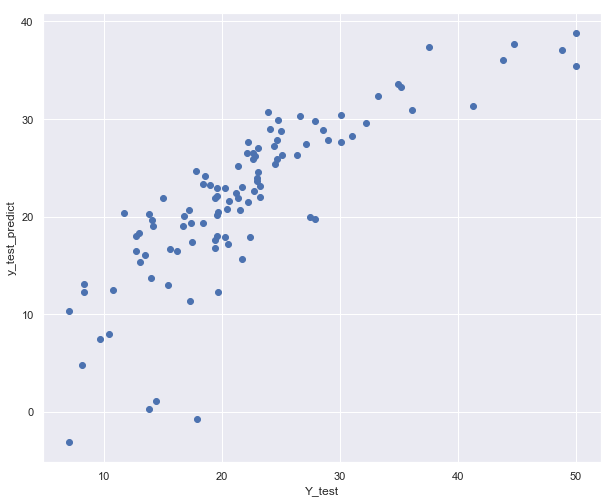

In [14]:
# plotting the y_test vs y_pred
# ideally should have been a straight line
plt.scatter(Y_test, y_test_predict, marker='o')
plt.xlabel('Y_test')
plt.ylabel('y_test_predict')
plt.show()


In [15]:
Check = np.c_[Y_test.values,y_test_predict]
print(Check)

[[37.6        37.38999403]
 [27.9        29.79290611]
 [22.6        25.86755297]
 [13.8         0.31370828]
 [35.2        33.31385559]
 [10.4         7.97136102]
 [23.9        30.7066387 ]
 [29.         27.83076842]
 [22.8        26.26693081]
 [23.2        21.97871678]
 [33.2        32.33149332]
 [19.         23.21791374]
 [20.3        22.9932889 ]
 [36.1        30.97465356]
 [24.4        27.19747687]
 [17.2        20.7171544 ]
 [17.9        -0.67524986]
 [19.6        18.01248654]
 [19.7        12.3108109 ]
 [15.         21.90615827]
 [ 8.1         4.82262227]
 [23.         24.00423026]
 [44.8        37.70279396]
 [23.1        24.59521859]
 [32.2        29.6355729 ]
 [10.8        12.5396288 ]
 [23.1        27.07081337]
 [21.2        22.44485896]
 [22.2        27.64895322]
 [24.1        28.99223597]
 [17.3        11.38689571]
 [ 7.         10.39119661]
 [12.7        18.02726641]
 [17.8        24.65916571]
 [26.4        26.3259374 ]
 [19.6        22.97547671]
 [25.1        26.32610451]
 